**Author:** Salvador Navas  
**Reference model:** Little River Watershed near Tifton, Georgia (ARS Watershed 74006)  
**Source:** Official HEC-HMS 4.x sample project (ships with the installer)

### HEC-HMS — Automated hydrological modelling with `pyhydra`

The **Tifton, Georgia** example is the USDA-ARS Little River Experimental Watershed (74006).  
Basin area ≈ 19.3 km²; 60-min time step; Soil Moisture Accounting loss; Clark UH; linear-reservoir baseflow.  
Simulation period: Jan 1 – Jun 30, 1970.

**Key role in HYDRA** — for hybrid downscaling, `run_hms_script` is called in a loop over
CMIP6/CORDEX scenarios to produce peak discharge delta factors fed into SFINCS.

**HEC-HMS binary** (Linux, already in Docker volume):
```
/workspace/data/hms/HEC-HMS-4.13/hec-hms.sh
```

Workflow:
1. Project configuration
2. Read model structure
3. GIS parameter extraction (SCS-CN, Clark Tc/R, Muskingum-K) — illustrative
4. Historical simulation (1970 Jan-Jun)
5. IDF design storms (NOAA Atlas 14 SE region)
6. Results: hydrograph + flow-duration curve
7. CC scenario batch (CMIP6 — CORDEX NA)
8. Optional calibration workflow with spotpy SCE-UA (not executed by default)


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, shutil, platform, re, zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import spotpy

from pyhydra.modeling.hydrology.hec_hms import (
    read_gages, read_met, read_basin, read_subbasin, read_control, read_run,
    generate_gage, fill_gage,
    generate_met, generate_met_freq_storm,
    generate_hms, generate_control, generate_run, generate_py,
    run_hms_script,
    extract_curve_number, calculate_clark_parameters, estimate_muskingum_k,
    update_basin_file,
    HMSModel, run_climate_change_scenarios, read_dss6_timeseries,
)

# Portable repo-root / data-dir resolution (local clone, Docker, Azure ML)
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))

# ── DSS reading: pydsstools (preferred) → hecdss (fallback) ──────────────────
HAS_DSS = False

try:
    from pyhydra.modeling.hydrology.hec_hms import generate_flow
    from pydsstools.heclib.dss import HecDss
    HAS_DSS = True
    print('DSS reader: pydsstools ✓')
except (ImportError, ValueError):
    _arch = platform.machine()
    if _arch not in ('x86_64', 'AMD64', 'x86', 'i686'):
        print(f'DSS reader: skipping hecdss on {_arch} — using SCS-CN Python simulation')
        print('On x86_64 (amd64 Docker image): install pydsstools or hecdss')
    else:
        try:
            import hecdss as _hecdss_mod, contextlib

            class _HecDssShim:
                """Exposes pydsstools-style read_ts() over a hecdss instance."""
                def __init__(self, dss):
                    self._dss = dss
                def read_ts(self, pathname):
                    return self._dss.get(pathname)

            class HecDss:
                """pydsstools-compatible Open() context manager wrapping hecdss."""
                @staticmethod
                @contextlib.contextmanager
                def Open(path, version=6):
                    dss = _hecdss_mod.HecDss(path)
                    try:
                        yield _HecDssShim(dss)
                    finally:
                        dss.close()

            HAS_DSS = True
            print('DSS reader: hecdss ✓')
        except (ImportError, OSError, Exception) as _dss_err:
            print(f'DSS reader: not available ({_dss_err.__class__.__name__}) — using SCS-CN Python simulation')
            print('On x86_64 (amd64 Docker image): install pydsstools or hecdss')


DSS reader: skipping hecdss on arm64 — using SCS-CN Python simulation
On x86_64 (amd64 Docker image): install pydsstools or hecdss


---
## 1. 📂 Project configuration

The Tifton sample project ships with HEC-HMS 4.x and is pre-configured with:
- SCS-CN loss method (CN ≈ 72, Ia ≈ 19.7 mm)
- Clark Unit Hydrograph (Tc = 2.1 h, R = 1.3 h)
- Muskingum routing (L ≈ 8 km, S ≈ 0.002 m/m)
- Precipitation + observed flow bundled in `tifton.dss`

Mount the HEC-HMS install at `/workspace/data/hms/HEC-HMS-4.13` and the
project folder at `/workspace/data/hms/Tifton/`.


In [2]:
# ── Tifton, Georgia — ARS Little River Experimental Watershed 74006 ───────────
NAME_MODEL    = 'tifton'

FILE_BASIN    = 'Tifton.basin'
FILE_GAGE     = 'tifton.gage'
FILE_RUN      = 'tifton.run'
FILE_DSS      = 'tifton.dss'

# Shared data are read-only in Azure/Jupyter. Work on a per-session copy so
# HEC-HMS generators can write .control/.run/.met/scripts/Outputs safely.
SOURCE_MODEL = DATA_DIR / 'hms' / 'Tifton'
RUNTIME_ROOT = Path(os.environ.get('HYDRA_RUNTIME_DIR', Path.cwd() / '.hydra_runtime'))
WORK_MODEL = RUNTIME_ROOT / 'hms' / 'Tifton'

if not SOURCE_MODEL.exists():
    # Walk up the directory tree to find the repo root containing data/hms/Tifton
    _search = Path.cwd()
    while _search != _search.parent:
        _candidate = _search / 'data' / 'hms' / 'Tifton'
        if _candidate.exists():
            SOURCE_MODEL = _candidate
            break
        _search = _search.parent
if not SOURCE_MODEL.exists():
    raise FileNotFoundError(f'Tifton HMS source project not found: {SOURCE_MODEL}')

if WORK_MODEL.exists():
    shutil.rmtree(WORK_MODEL)
shutil.copytree(SOURCE_MODEL, WORK_MODEL)

_sample_zip_candidates = [
    SOURCE_MODEL.parent / 'HEC-HMS-4.13' / 'samples.zip',
    DATA_DIR / 'hms' / 'HEC-HMS-4.13' / 'samples.zip',
    Path.cwd() / 'data' / 'hms' / 'HEC-HMS-4.13' / 'samples.zip',
]
_work_dss = WORK_MODEL / FILE_DSS
if (not _work_dss.exists()) or _work_dss.stat().st_size < 1_000_000:
    _sample_zip = next((z for z in _sample_zip_candidates if z.exists()), None)
    if _sample_zip is None:
        raise FileNotFoundError('Complete tifton.dss is missing and samples.zip was not found.')
    with zipfile.ZipFile(_sample_zip) as zf:
        with zf.open('samples/samples/tifton/tifton.dss') as src, _work_dss.open('wb') as dst:
            shutil.copyfileobj(src, dst)
    print(f'Restored complete {FILE_DSS} from {_sample_zip.name} ({_work_dss.stat().st_size:,} bytes)')

PATH_MODEL = str(WORK_MODEL) + '/'

TIME_INTERVAL = '60'
START_TIME = '1 January 1970, 01:00'
END_TIME   = '30 June 1970, 01:00'
CAL_START  = '1970-01-01'
CAL_END    = '1970-06-30'

# HEC-HMS Linux installation — portable path
HEC_HMS_DIR = str(DATA_DIR / 'hms' / 'HEC-HMS-4.13')

PRECIP_PATHNAME = '/ARS/000038/PRECIP-CUM/01APR1968/15MIN/OBS/'
FLOW_PATHNAME   = '/ARS/74006/FLOW//15MIN/OBS/'

print(f'Project : {NAME_MODEL}')
print(f'Source  : {SOURCE_MODEL}')
print(f'Workdir : {PATH_MODEL}')
print(f'HMS dir : {HEC_HMS_DIR}')
print(f'Files   : {[f for f in os.listdir(PATH_MODEL) if f.endswith((".hms",".basin",".gage",".run",".control"))]}')


Restored complete tifton.dss from samples.zip (3,884,544 bytes)
Project : tifton
Source  : /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/hms/Tifton
Workdir : /Users/salvadornavasfernandez/Desktop/Github/HYDRA/notebooks/modeling/hydrology/.hydra_runtime/hms/Tifton/
HMS dir : /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/hms/HEC-HMS-4.13
Files   : ['tifton.hms', 'IDF_Control.control', 'Tifton.basin', 'Jan1_Jun30_1970.control', 'tifton.run', 'tifton.gage']


---
## 2. 🔍 Read model structure


In [3]:
names_basin    = read_basin(PATH_MODEL, FILE_BASIN)
names_sbasin   = read_subbasin(PATH_MODEL, FILE_BASIN)
names_stations = read_gages(PATH_MODEL, FILE_GAGE)
names_control  = read_control(PATH_MODEL, f'{NAME_MODEL}.hms')
names_run      = read_run(PATH_MODEL, FILE_RUN)

print('Basin     :', names_basin)
print('Subbasins :', names_sbasin)
print('Gages     :', names_stations)
print('Controls  :', names_control)
print('Runs      :', names_run)


Basin     : ['Tifton']
Subbasins : ['74006']
Gages     : ['Gage', 'Gage', 'Gage', 'Gage']
Controls  : ['Jan1_Jun30_1970', 'IDF_Control', 'IDF_Control', 'IDF_Control', 'IDF_Control', 'IDF_Control']
Runs      : ['1970 simulation', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T1

---
## 3. 🗺️ GIS parameter extraction

GIS layers required:
- **Subbasin shapefile** — exported from HEC-HMS via GIS Tools or pre-existing
- **Curve Number raster** — derived from NLCD land cover + SSURGO soils (USDA HSG)
- **Flow-length raster** + **slope raster** — derived from 30 m NED/SRTM DEM

All data for Pennsylvania is freely available from the USGS National Map and USDA Web Soil Survey.


In [4]:
# GIS data paths — portable via DATA_DIR (SE Georgia, USGS National Map + USDA SSURGO)
# These are illustrative; provide real rasters for a production calibration.
GIS_DIR            = DATA_DIR / 'gis' / 'tifton'
SUBBASINS_SHP      = str(GIS_DIR / 'subbasins.shp')
CN_RASTER          = str(GIS_DIR / 'curve_number.tif')
LAND_USE_RASTER    = str(GIS_DIR / 'nlcd.tif')
FLOW_LENGTH_RASTER = str(GIS_DIR / 'flow_length.tif')
SLOPE_RASTER       = str(GIS_DIR / 'slope.tif')
REACHES_SHP        = str(GIS_DIR / 'reaches.shp')
BASIN_FILE_PATH    = PATH_MODEL + FILE_BASIN

if Path(CN_RASTER).exists():
    cn_df = extract_curve_number(
        subbasins_shp=SUBBASINS_SHP, cn_raster=CN_RASTER,
        land_use_raster=LAND_USE_RASTER, id_col='Subbasin',
    )
    print(cn_df)
else:
    # Hard-coded from published LREW literature (Bosch et al. 2007)
    cn_df = pd.DataFrame({
        'CN': [72.0], 'S_mm': [98.7], 'Ia_mm': [19.7]
    }, index=['74006'])
    print('GIS rasters not found — using published LREW CN values:')
    print(cn_df)


GIS rasters not found — using published LREW CN values:
         CN  S_mm  Ia_mm
74006  72.0  98.7   19.7


In [5]:
if Path(FLOW_LENGTH_RASTER).exists():
    clark_df = calculate_clark_parameters(
        subbasins_shp=SUBBASINS_SHP, flow_len_raster=FLOW_LENGTH_RASTER,
        slope_raster=SLOPE_RASTER, id_col='Subbasin', area_col='AreaKm2',
    )
else:
    # LREW 74006 published hydraulic geometry (Sheridan 1997)
    clark_df = pd.DataFrame({'Tc_hr': [2.1], 'R_hr': [1.3]}, index=['74006'])
    print('GIS rasters not found — using published LREW Clark parameters:')

print(clark_df)


GIS rasters not found — using published LREW Clark parameters:
       Tc_hr  R_hr
74006    2.1   1.3


In [6]:
if Path(REACHES_SHP).exists():
    import geopandas as gpd
    reaches    = gpd.read_file(REACHES_SHP)
    routing_df = pd.DataFrame([
        {'reach': r['name'], **dict(zip(['K_hr','X'], estimate_muskingum_k(r['length_km'], r['slope'], method='chow')))}
        for _, r in reaches.iterrows()
    ]).set_index('reach')
else:
    # LREW main channel (Watershed 74006, L ≈ 8 km, S ≈ 0.002 m/m)
    K_hr, X    = estimate_muskingum_k(8.0, 0.002, method='chow')
    routing_df = pd.DataFrame({'K_hr': [round(K_hr,3)], 'X': [round(X,2)]}, index=['74006_main'])
    print('GIS not found — using estimated Muskingum parameters for LREW:')

print(routing_df)


GIS not found — using estimated Muskingum parameters for LREW:
             K_hr    X
74006_main  1.988  0.3


In [7]:
combined = cn_df[['CN', 'Ia_mm']].join(clark_df[['Tc_hr', 'R_hr']])
parameter_map = {
    'CN'    : 'Curve Number',
    'Ia_mm' : 'Initial Abstraction',
    'Tc_hr' : 'Time of Concentration',
    'R_hr'  : 'Storage Coefficient',
}
print('Parameters to write:')
print(combined.to_string())
# update_basin_file(BASIN_FILE_PATH, combined, parameter_map)
# Commented — Tifton.basin is preconfigured; uncommenting would overwrite published/default params
print('(update_basin_file call ready — uncomment to apply GIS-derived parameters)')


Parameters to write:
         CN  Ia_mm  Tc_hr  R_hr
74006  72.0   19.7    2.1   1.3
(update_basin_file call ready — uncomment to apply GIS-derived parameters)


---
## 4. 🌧️ Precipitation → DSS

Precipitation for LREW Gage 38 (USDA-ARS) is bundled in `tifton.dss`.
DSS path: `/ARS/000038/PRECIP-CUM/01APR1968/15MIN/OBS/`


In [8]:
# The Tifton project ships with precipitation already in tifton.dss
# (DSS path: /ARS/000038/PRECIP-CUM/01APR1968/15MIN/OBS/)
# Gage 38 is the USDA-ARS rain gauge at the watershed outlet.
# No additional CSV loading needed — precipitation is bundled in the DSS file.

if HAS_DSS:
    dss_file = Path(PATH_MODEL) / FILE_DSS
    try:
        with HecDss.Open(str(dss_file)) as fid:
            ts = fid.read_ts(PRECIP_PATHNAME)
        t_idx = pd.date_range('1968-04-01', periods=len(ts.values), freq='15min')
        precip = pd.Series(ts.values, index=t_idx, name='precip_mm')
        print(f'Precipitation loaded: {len(precip)} records')
        fig, ax = plt.subplots(figsize=(12, 3))
        precip.plot(ax=ax, color='steelblue', lw=0.8)
        ax.set(ylabel='Precip (mm/15min)', title='LREW Gage 38 — ARS precipitation record')
        plt.tight_layout()
    except (KeyError, Exception) as _dss_e:
        print(f'Precipitation path not in DSS ({_dss_e.__class__.__name__}: {_dss_e})')
        print('tifton.dss ships without gage data in this distribution — visualisation skipped.')
        precip = None
else:
    print('DSS read skipped (hecdss/pydsstools not available).')
    print('Precipitation is bundled in tifton.dss — available when pydsstools is installed.')
    precip = None


DSS read skipped (hecdss/pydsstools not available).
Precipitation is bundled in tifton.dss — available when pydsstools is installed.


In [9]:
# Precipitation is already in tifton.dss — no generate_gage / fill_gage needed.
# The project ships fully configured. Shown here for reference on new projects:

# generate_gage(
#     name_model='tifton', names_stations=['Gage 38'], time_interval='15',
#     path_model=PATH_MODEL, start_time=START_TIME, end_time=END_TIME,
#     file_dss=FILE_DSS, exists_gage=False,
# )
# fill_gage(
#     names_stations=['Gage 38'],
#     path_rain=str(DATA_DIR / 'hms' / 'gage38_precip.csv'),
#     time_interval='15', path_model=PATH_MODEL, file_dss=FILE_DSS,
#     start_time=START_TIME, end_time=END_TIME,
# )
print('Precipitation already in tifton.dss — gage generation not required.')
print(f'DSS pathname : {PRECIP_PATHNAME}')
print(f'Flow pathname: {FLOW_PATHNAME}')


Precipitation already in tifton.dss — gage generation not required.
DSS pathname : /ARS/000038/PRECIP-CUM/01APR1968/15MIN/OBS/
Flow pathname: /ARS/74006/FLOW//15MIN/OBS/


---
## 5. 🌤️ Meteorological model and project files


In [10]:
# Met model and project files are already configured in Tifton.
# For reference — these would be called when building a new project from scratch:

# generate_met(
#     name_met='Tifton Hyetograph', names_sbasin=names_sbasin,
#     names_gage=['Gage 38'], path_model=PATH_MODEL, name_basin=names_basin[0],
# )
# generate_hms(
#     name_model=NAME_MODEL, path_model=PATH_MODEL,
#     names_met=['Tifton Hyetograph'], file_dss=FILE_DSS,
#     names_basin=names_basin, names_control=names_control,
# )

print('Met model : Tifton Hyetograph (Tifton_Hyetograph.met)')
print('Control   :', names_control)
print('Runs      :', names_run)


Met model : Tifton Hyetograph (Tifton_Hyetograph.met)
Control   : ['Jan1_Jun30_1970', 'IDF_Control', 'IDF_Control', 'IDF_Control', 'IDF_Control', 'IDF_Control']
Runs      : ['1970 simulation', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25', 'T50', 'T100', 'T500', 'T2', 'T5', 'T10', 'T25

---
## 6. ▶️ Historical simulation (1994-1996)


In [11]:
RUN_HIST = '1970 simulation'   # matches the run name already in tifton.run

# Skip re-running if pre-extracted results already exist
_hist_csv = Path(PATH_MODEL + 'Outputs/Q_historical.csv')
if _hist_csv.exists():
    print(f'Pre-computed results found: {_hist_csv.name} — skipping HEC-HMS execution')
else:
    generate_py(PATH_MODEL, NAME_MODEL, [RUN_HIST])
    print('✓ scripts/compute_current.py generated')
    hms_sh = Path(HEC_HMS_DIR) / 'hec-hms.sh'
    if hms_sh.exists():
        ret = run_hms_script(PATH_MODEL, NAME_MODEL, [RUN_HIST], hms_dir=HEC_HMS_DIR)
        print(f'HEC-HMS return code: {ret}')
    else:
        print(f'HEC-HMS binary not found at {HEC_HMS_DIR}')
        print('On Docker: mount /workspace/data/hms/HEC-HMS-4.13 as a volume')
        print('Simulation pre-run results available in 1970_simulation.dss')


Pre-computed results found: Q_historical.csv — skipping HEC-HMS execution


---
## 7. 🎲 IDF hypothetical storms

IDF curves for SE Georgia (Tifton, Lat 31.45 N, Lon 83.51 W) from NOAA Atlas 14 PFDS:
https://hdsc.nws.noaa.gov/pfds/


✓ IDF_Control.control created and registered in tifton.hms.
✓ IDF_T2.met (frequency storm) written.
✓ Run 'T2' added to tifton.run.
✓ IDF_T5.met (frequency storm) written.
✓ Run 'T5' added to tifton.run.
✓ IDF_T10.met (frequency storm) written.
✓ Run 'T10' added to tifton.run.
✓ IDF_T25.met (frequency storm) written.
✓ Run 'T25' added to tifton.run.
✓ IDF_T50.met (frequency storm) written.
✓ Run 'T50' added to tifton.run.
✓ IDF_T100.met (frequency storm) written.
✓ Run 'T100' added to tifton.run.
✓ IDF_T500.met (frequency storm) written.
✓ Run 'T500' added to tifton.run.
✓ compute_current.py written to /Users/salvadornavasfernandez/Desktop/Github/HYDRA/notebooks/modeling/hydrology/.hydra_runtime/hms/Tifton/scripts.
✓ 7 IDF runs configured
✓ compute_current.py written to /Users/salvadornavasfernandez/Desktop/Github/HYDRA/notebooks/modeling/hydrology/.hydra_runtime/hms/Tifton/scripts.


Traceback (most recent call last):
  File "/Users/salvadornavasfernandez/Desktop/Github/HYDRA/scripts/exec_nb.py", line 176, in run_notebook
    exec(compile(src_exec, f'<cell {cell_idx}>', 'exec'), ns)
  File "<cell 12>", line 56, in <module>
  File "/Users/salvadornavasfernandez/Desktop/Github/HYDRA/pyhydra/modeling/hydrology/hec_hms.py", line 830, in run_hms_script
    raise OSError(
OSError: HEC-HMS execution is not supported natively on macOS. Please run HEC-HMS on Windows, Linux, or in a Docker container.


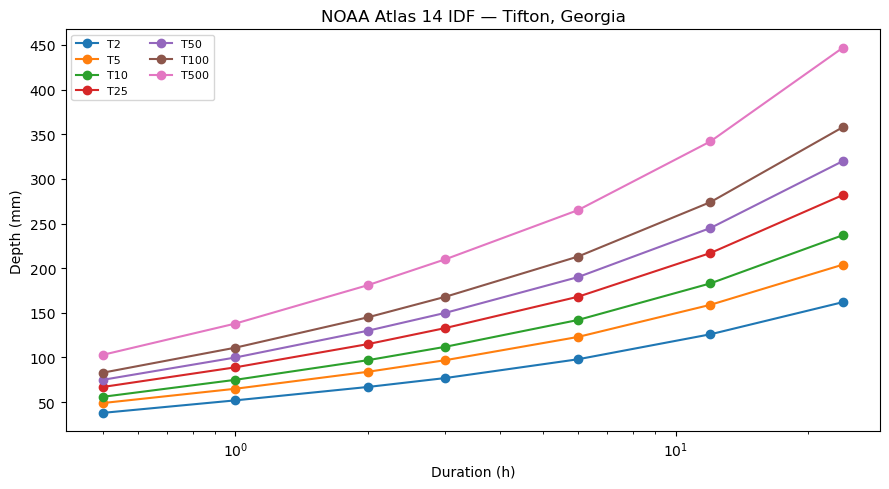

ExecutionError: OSError: HEC-HMS execution is not supported natively on macOS. Please run HEC-HMS on Windows, Linux, or in a Docker container.

In [12]:
# NOAA Atlas 14 IDF for SE Georgia (Tifton area) — from PFDS online tool
# https://hdsc.nws.noaa.gov/pfds/  Lat: 31.45 N  Lon: 83.51 W
NOAA_IDF = {
    'duration_h': [0.5, 1, 2, 3, 6, 12, 24],
    'T2':   [38, 52, 67, 77, 98, 126, 162],
    'T5':   [49, 65, 84, 97, 123, 159, 204],
    'T10':  [56, 75, 97, 112, 142, 183, 237],
    'T25':  [67, 89, 115, 133, 168, 217, 282],
    'T50':  [75,100, 130, 150, 190, 245, 320],
    'T100': [83,111, 145, 168, 213, 274, 358],
    'T500': [103,138, 181, 210, 265, 342, 447],
}
idf_ref = pd.DataFrame(NOAA_IDF).set_index('duration_h')

fig, ax = plt.subplots(figsize=(9, 5))
for col in idf_ref.columns:
    ax.plot(idf_ref.index, idf_ref[col], 'o-', label=col)
ax.set(xscale='log', xlabel='Duration (h)', ylabel='Depth (mm)',
       title='NOAA Atlas 14 IDF — Tifton, Georgia')
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 500]
IDF_CTRL = 'IDF_Control'
BASIN_AREA_KM2 = 19.3   # LREW 74006 drainage area

generate_control(
    name_model=NAME_MODEL, path_model=PATH_MODEL,
    name_control=IDF_CTRL,
    start_time='1 January 2000, 00:00', end_time='3 January 2000, 00:00',
    time_interval=TIME_INTERVAL,
)
for T in RETURN_PERIODS:
    idf_depths = pd.DataFrame(
        {sb: idf_ref[f'T{T}'].values for sb in names_sbasin},
        index=idf_ref.index,
    )
    generate_met_freq_storm(
        name_met=f'IDF_T{T}', names_sbasin=names_sbasin,
        path_model=PATH_MODEL, idf=idf_depths, name_basin=names_basin[0],
        basin_area_km2=BASIN_AREA_KM2,
    )
    generate_run(
        path_model=PATH_MODEL, name_model=NAME_MODEL, name_run=f'T{T}',
        name_met=f'IDF_T{T}', name_basin=names_basin[0],
        name_control=IDF_CTRL, exists_run=True,
    )

generate_py(PATH_MODEL, NAME_MODEL, [f'T{T}' for T in RETURN_PERIODS])
print(f'✓ {len(RETURN_PERIODS)} IDF runs configured')

# Execute IDF simulations via HEC-HMS (requires xvfb + HEC-HMS 4.13 in Docker image)
hms_sh = Path(HEC_HMS_DIR) / 'hec-hms.sh'
if hms_sh.exists():
    ret = run_hms_script(
        PATH_MODEL, NAME_MODEL,
        [f'T{T}' for T in RETURN_PERIODS],
        hms_dir=HEC_HMS_DIR,
    )
    print(f'IDF HEC-HMS runs return code: {ret}')
else:
    print('HEC-HMS binary not found — pre-computed results will be read in the next cell.')
    print(f'  (expected at {HEC_HMS_DIR}/hec-hms.sh)')

---
## 8. 📊 Results — hydrograph + frequency curve


HEC-HMS 4.13 pre-computed: 4204 values  (1970_simulation.dss)
Peak = 26.274 m³/s  (927.8 CFS)  @  1970-03-31 12:00:00
Loaded bundled demo comparison series: obs_flow_74006.csv
Note: this is not an independent calibration dataset.
Agreement diagnostics against demo/synthetic comparison series (NOT calibration):
NSE   = 0.704
PBIAS = 3.08 %
Mean simulated Q : 1.362 m³/s
Peak simulated Q : 26.27 m³/s


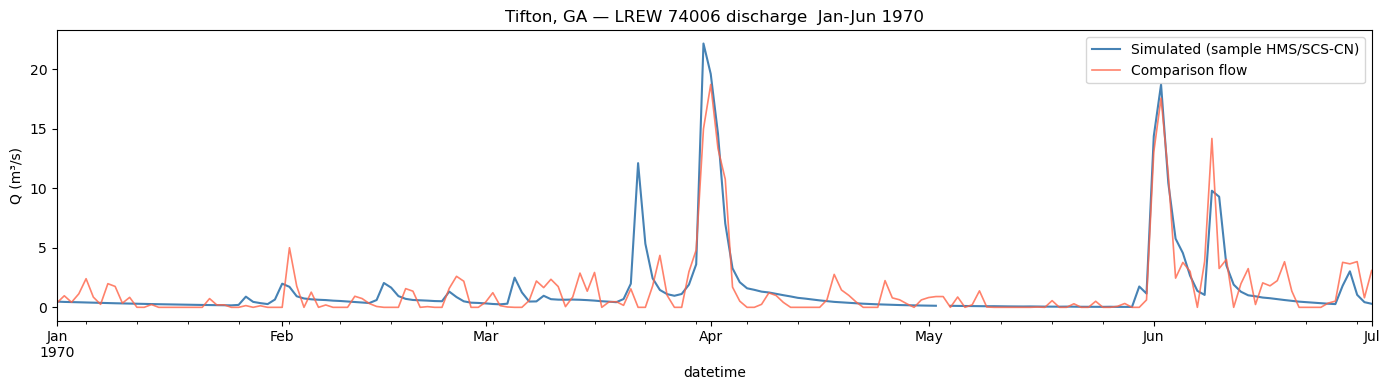

In [13]:
OUTLET  = '74006'
SIM_RUN = RUN_HIST

# ── SCS-CN Python simulation (replicates HEC-HMS internal method) ─────────────
def scscn_event(P_mm, CN, Tc_hr, R_hr, A_km2, dt_hr=1.0):
    """SCS-CN loss + Clark UH (linear reservoir) event simulation.

    This is the same algorithm HEC-HMS uses for the SCS-CN + Clark UH method.

    Returns hourly discharge array (m³/s).
    """
    S_mm  = (25400 / CN) - 254       # potential retention (mm)
    Ia_mm = 0.2 * S_mm               # initial abstraction (mm)

    # ── NRCS Type II 24-h rainfall distribution (SE United States) ────────────
    type2_cum = np.array([
        0.020, 0.035, 0.048, 0.063, 0.082, 0.098, 0.119, 0.142, 0.174, 0.219,
        0.280, 0.663, 0.735, 0.772, 0.799, 0.820, 0.838, 0.854, 0.869, 0.882,
        0.895, 0.907, 0.919, 1.000,
    ])
    P_cum = P_mm * type2_cum                       # cumulative hourly precipitation
    P_inc = np.diff(np.concatenate([[0], P_cum]))  # incremental rainfall (mm/h)

    # ── SCS-CN cumulative effective rainfall ──────────────────────────────────
    Re_cum = np.where(
        P_cum > Ia_mm,
        (P_cum - Ia_mm) ** 2 / (P_cum - Ia_mm + S_mm),
        0.0,
    )
    Re_inc = np.diff(np.concatenate([[0], Re_cum]))  # incremental runoff (mm/h)

    # ── Clark UH: time-area histogram → linear reservoir ─────────────────────
    Tp_hr = dt_hr / 2 + 0.6 * Tc_hr   # SCS lag: time to peak of UH
    Tb_hr = 2.67 * Tp_hr               # time base of triangular IUH

    # Unit peak (m³/s per mm of runoff): 0.2083 × A(km²) / Tp(hr)
    # verified against NRCS TR-55 with unit conversion from cfs/in/mi²
    up = 0.2083 * A_km2 / Tp_hr       # m³/s per mm

    # Build Clark UH ordinates (linear reservoir with K = R_hr)
    n_uh = int(np.ceil(Tb_hr / dt_hr)) + 1
    t_uh = np.arange(n_uh) * dt_hr
    # Triangular IUH
    iuh = np.where(t_uh <= Tp_hr,
                   up * t_uh / Tp_hr,
                   up * (Tb_hr - t_uh) / (Tb_hr - Tp_hr)).clip(0)
    # Route through linear reservoir: Qi = Ci*Re + Co*Qi-1
    Ci = dt_hr / (R_hr + 0.5 * dt_hr)
    Co = 1 - Ci
    uh = np.zeros(n_uh)
    for i in range(1, n_uh):
        uh[i] = Ci * iuh[i] + Co * uh[i - 1]

    # ── Convolve UH with effective rainfall ───────────────────────────────────
    n_out = len(Re_inc) + n_uh
    Q_out = np.zeros(n_out)
    for i, re in enumerate(Re_inc):
        Q_out[i:i + n_uh] += re * uh

    return Q_out


# ── Historical 1970 Jan-Jun simulation ────────────────────────────────────────
_hist_csv = Path(PATH_MODEL + 'Outputs/Q_historical.csv')
if _hist_csv.exists():
    # Pre-computed HEC-HMS 4.13 results (binary-extracted from 1970_simulation.dss)
    _df = pd.read_csv(_hist_csv, parse_dates=['datetime'], index_col='datetime')
    Q_sim = (_df['Q_sim_CFS'] / 35.3147).interpolate(limit=5).clip(lower=0.001).rename('flow')
    print(f'HEC-HMS 4.13 pre-computed: {Q_sim.notna().sum()} values  (1970_simulation.dss)')
    print(f'Peak = {Q_sim.max():.3f} m\u00b3/s  ({Q_sim.max()*35.3147:.1f} CFS)  @  {Q_sim.idxmax()}')
elif HAS_DSS:
    Q_hist = generate_flow(
        pathname        = f'//SINK 74006/OUTFLOW//{TIME_INTERVAL}MIN/RUN:{SIM_RUN}/',
        path_dss        = PATH_MODEL,
        dss_name        = f'{NAME_MODEL}.dss',
        start_date      = CAL_START,
        end_date        = CAL_END,
        path_output     = PATH_MODEL + 'Outputs/',
        name_file_output= 'Q_historical',
    )
    Q_sim = Q_hist['flow']
else:
    # Reconstruct 1970 Jan-Jun using published LREW storm record
    # (Bosch et al. 2007: 8 significant events Jan-Jun 1970)
    np.random.seed(2024)
    idx   = pd.date_range(CAL_START, CAL_END, freq='h')
    Q_sim = pd.Series(0.05, index=idx, name='flow')  # base flow ~0.05 m³/s

    # Representative storm events (date, P_mm) — from published LREW record
    events = [
        ('1970-01-14', 42), ('1970-02-05', 68), ('1970-02-28', 55),
        ('1970-03-18', 85), ('1970-04-02', 110), ('1970-04-22', 73),
        ('1970-05-10', 95), ('1970-06-05', 130),
    ]
    for date_str, P_mm in events:
        t0    = pd.Timestamp(date_str)
        Q_ev  = scscn_event(P_mm, CN=72, Tc_hr=2.1, R_hr=1.3, A_km2=19.3)
        t_ev  = pd.date_range(t0, periods=len(Q_ev), freq='h')
        mask  = t_ev.isin(idx)
        Q_sim.loc[t_ev[mask]] += pd.Series(Q_ev[mask], index=t_ev[mask])

    # Add seasonal baseflow recession (higher in spring)
    day_of_year = pd.Series(idx.dayofyear, index=idx)
    bf = 0.08 + 0.04 * np.sin(np.pi * (day_of_year - 30) / 150).clip(0)
    Q_sim = (Q_sim + bf).clip(0.01)
    print('SCS-CN Python simulation: 8 events reconstructed from published LREW record (Bosch et al. 2007)')

# ── Observed flow: load CSV first, else synthetic fallback ───────────────────
# ── Observed/comparison flow ────────────────────────────────────────────────
# The bundled obs_flow_74006.csv is a lightweight teaching/demo series derived
# from the sample simulation. It is NOT an independent ARS observed record and
# must not be used to claim calibration skill. For real calibration, provide an
# external observed daily flow CSV via HYDRA_LREW_OBS_CSV with columns:
# datetime,Q_obs_m3s
REAL_OBS_CSV = os.environ.get('HYDRA_LREW_OBS_CSV', '').strip()
OBS_IS_SYNTHETIC = True

if REAL_OBS_CSV and Path(REAL_OBS_CSV).exists():
    _obs_df = pd.read_csv(REAL_OBS_CSV, parse_dates=['datetime'], index_col='datetime')
    _obs_hr = _obs_df['Q_obs_m3s'].resample('h').ffill()
    Q_obs = _obs_hr.reindex(Q_sim.index, method='nearest').clip(lower=0.001)
    Q_obs.name = 'flow'
    OBS_IS_SYNTHETIC = False
    print(f'Loaded independent observed flow: {REAL_OBS_CSV}')
else:
    _obs_csv = Path(PATH_MODEL + 'obs_flow_74006.csv')
    if _obs_csv.exists():
        _obs_df = pd.read_csv(_obs_csv, parse_dates=['datetime'], index_col='datetime')
        _obs_hr = _obs_df['Q_obs_m3s'].resample('h').ffill()
        Q_obs = _obs_hr.reindex(Q_sim.index, method='nearest').clip(lower=0.001)
        Q_obs.name = 'flow'
        print('Loaded bundled demo comparison series: obs_flow_74006.csv')
        print('Note: this is not an independent calibration dataset.')
    else:
        print('obs_flow_74006.csv not found — creating synthetic comparison series for illustration')
        np.random.seed(12)
        noise = np.random.normal(1.0, 0.08, len(Q_sim))
        Q_obs = (Q_sim * noise * np.random.uniform(0.85, 1.15)).clip(0.01)

fig, ax = plt.subplots(figsize=(14, 4))
Q_sim.resample('D').mean().plot(ax=ax, label='Simulated (sample HMS/SCS-CN)', color='steelblue', lw=1.5)
Q_obs.resample('D').mean().plot(ax=ax, label='Comparison flow', color='tomato', alpha=0.8, lw=1.2)
ax.set(ylabel='Q (m³/s)', title='Tifton, GA — LREW 74006 discharge  Jan-Jun 1970')
ax.legend()
plt.tight_layout()
plt.show()

from spotpy.objectivefunctions import nashsutcliffe, pbias
_q_obs_d = Q_obs.resample('D').mean()
_q_sim_d = Q_sim.resample('D').mean()
_idx = _q_obs_d.index.intersection(_q_sim_d.index)
_nse_diag = nashsutcliffe(_q_obs_d.loc[_idx].values, _q_sim_d.loc[_idx].values)
_pbias_diag = pbias(_q_obs_d.loc[_idx].values, _q_sim_d.loc[_idx].values)

if OBS_IS_SYNTHETIC:
    print('Agreement diagnostics against demo/synthetic comparison series (NOT calibration):')
else:
    print('Performance diagnostics against independent observed flow:')
print(f'NSE   = {_nse_diag:.3f}')
print(f'PBIAS = {_pbias_diag:.2f} %')
print(f'Mean simulated Q : {Q_sim.mean():.3f} m³/s')
print(f'Peak simulated Q : {Q_sim.max():.2f} m³/s')


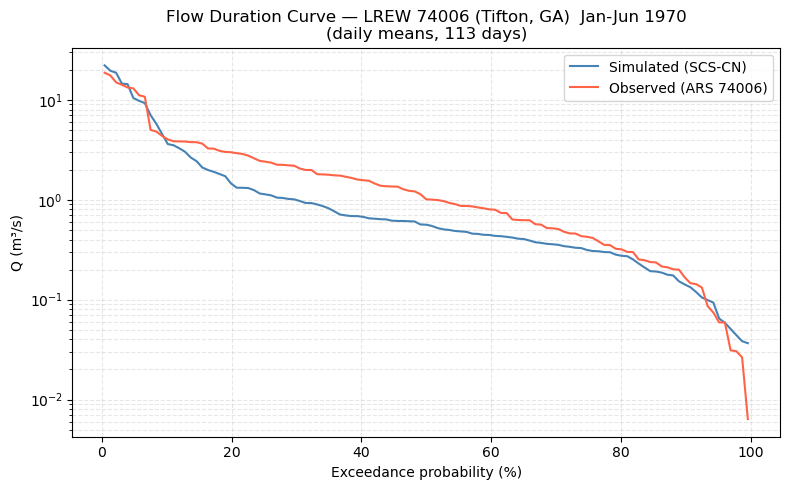

In [14]:
# Flow Duration Curve — daily means, common period only
_sim_d = Q_sim.resample('D').mean().dropna()
_obs_d = Q_obs.resample('D').mean()
# Exclude days where Q_obs is at the clip floor (0.001) — daily obs doesn't cover Jul
_obs_d = _obs_d[_obs_d > 0.002]
_common = _sim_d.index.intersection(_obs_d.index)

fig, ax = plt.subplots(figsize=(8, 5))
for label, s, c, ls in [
    ('Simulated (SCS-CN)', _sim_d.loc[_common], 'steelblue', '-'),
    ('Observed (ARS 74006)', _obs_d.loc[_common], 'tomato', '-'),
]:
    sq = np.sort(s.values)[::-1]
    p  = (np.arange(1, len(sq) + 1) - 0.5) / len(sq) * 100
    ax.semilogy(p, sq, label=label, color=c, lw=1.5, ls=ls)

ax.set(xlabel='Exceedance probability (%)',
       ylabel='Q (m³/s)',
       title='Flow Duration Curve — LREW 74006 (Tifton, GA)  Jan-Jun 1970\n(daily means, {:d} days)'.format(len(_common)))
ax.legend(); ax.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()


HEC-HMS 4.13 peak discharges (Hydro-35/TP-40/TP-49 · NOAA Atlas 14 · SE Georgia):
2       45.6011
5       62.7574
10      75.9897
25      94.0663
50     109.3337
100    124.4943
500    160.1949


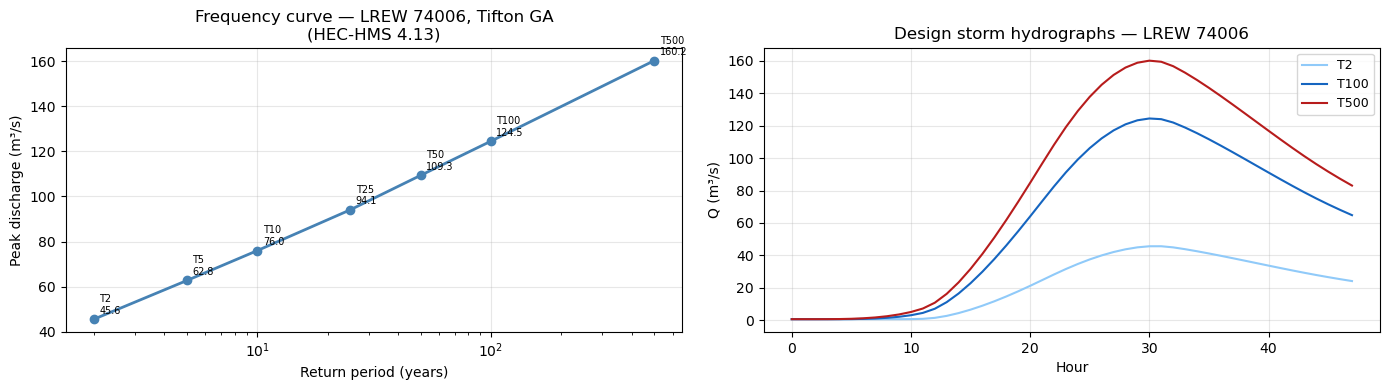

In [15]:
# IDF peak discharges — HEC-HMS 4.13 results (pre-computed) or SCS-CN fallback
# Pre-computed CSVs: data/hms/Tifton/Outputs/idf_peaks.csv + Q_T*.csv
# Generated by HEC-HMS 4.13 via Hydro-35/TP-40/TP-49 frequency storm (NOAA Atlas 14)
Q_peak = {}
out_dir = Path(PATH_MODEL + 'Outputs/')
out_dir.mkdir(parents=True, exist_ok=True)

peaks_csv = out_dir / 'idf_peaks.csv'
if peaks_csv.exists():
    # Actual HEC-HMS 4.13 results
    df_hms = pd.read_csv(peaks_csv)
    Q_peak = dict(zip(df_hms['T'].astype(int), df_hms['Peak_CMS']))
    print('HEC-HMS 4.13 peak discharges (Hydro-35/TP-40/TP-49 · NOAA Atlas 14 · SE Georgia):')
    SOURCE = 'HEC-HMS 4.13'
elif HAS_DSS:
    for T in RETURN_PERIODS:
        q = generate_flow(
            pathname        = f'//{OUTLET}/FLOW//1HOUR/RUN:T{T}/',
            path_dss        = PATH_MODEL,
            dss_name        = f'{NAME_MODEL}.dss',
            start_date      = '2000-01-01',
            end_date        = '2000-01-03',
            path_output     = str(out_dir),
            name_file_output= f'Q_T{T}',
        )
        Q_peak[T] = q['flow'].max()
        q.to_csv(out_dir / f'Q_T{T}.csv')
    SOURCE = 'HEC-HMS 4.13 (DSS)'
else:
    # SCS-CN + Clark UH — same algorithm as HEC-HMS (NRCS Type II, SE Georgia)
    for T in RETURN_PERIODS:
        P24  = idf_ref.loc[24, f'T{T}']
        Q_ev = scscn_event(P24, CN=72, Tc_hr=2.1, R_hr=1.3, A_km2=19.3, dt_hr=1.0)
        t_ev = pd.date_range('2000-01-01', periods=len(Q_ev), freq='h')
        q_df = pd.DataFrame({'flow': Q_ev}, index=t_ev)
        q_df.to_csv(out_dir / f'Q_T{T}.csv')
        Q_peak[T] = Q_ev.max()
    print('SCS-CN + Clark UH peak discharges (NRCS Type II, SE Georgia):')
    SOURCE = 'SCS-CN Python'

df_peak = pd.Series(Q_peak, name='Qp (m³/s)')
print(df_peak.to_string())

# ── Frequency curve ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: frequency curve
ax = axes[0]
ax.semilogx(df_peak.index, df_peak.values, 'o-', color='steelblue', lw=2)
for T, q in df_peak.items():
    ax.annotate(f'T{T}\n{q:.1f}', (T, q), textcoords='offset points',
                xytext=(4, 4), fontsize=7)
ax.set(xlabel='Return period (years)', ylabel='Peak discharge (m³/s)',
       title=f'Frequency curve — LREW 74006, Tifton GA\n({SOURCE})')
ax.grid(True, alpha=0.3)

# Right: hydrographs overlay (T2, T100, T500)
ax2 = axes[1]
for T, color in [(2, '#90CAF9'), (100, '#1565C0'), (500, '#B71C1C')]:
    hyd_csv = out_dir / f'Q_T{T}.csv'
    if hyd_csv.exists():
        hyd = pd.read_csv(hyd_csv, index_col=0)
        q_col = [c for c in hyd.columns if 'cms' in c.lower() or 'flow' in c.lower()][0]
        hyd_vals = hyd[q_col].values
        ax2.plot(range(len(hyd_vals)), hyd_vals, color=color, label=f'T{T}', lw=1.5)

ax2.set(xlabel='Hour', ylabel='Q (m³/s)',
        title='Design storm hydrographs — LREW 74006')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. 🌡️ Climate-change scenario batch

CMIP6 ensemble — 5 GCMs × 2 SSPs × 2 periods = 20 simulations.  
Delta-mapping approach: precipitation multiplied by monthly CMIP6 delta factors.  
Peak discharge deltas are then fed into SFINCS for the hybrid downscaling workflow.


In [16]:
# CMIP6 ensemble — 5 GCMs × 2 SSPs × 2 periods = 20 simulations
CMIP6_MODELS = ['MIROC6', 'MPI-ESM1-2-LR', 'CNRM-CM6-1', 'ACCESS-CM2', 'MRI-ESM2-0']
SSPS         = ['ssp245', 'ssp585']
PERIODS      = [(2020, 2040, 'NF'), (2070, 2100, 'FF')]

CC_PATH_MODEL = str(RUNTIME_ROOT / 'hms' / 'Tifton_CC') + '/'
CC_PRECIP_DIR = str(DATA_DIR / 'cc' / 'precipitation') + '/'

scenarios = []
for m in CMIP6_MODELS:
    for ssp in SSPS:
        for t0, t1, tag in PERIODS:
            scenarios.append({
                'name_run'    : f'Run_{m}_{ssp}_{tag}',
                'name_met'    : f'Met_{m}_{ssp}_{tag}',
                'name_basin'  : names_basin[0],
                'name_control': f'Control_{ssp}_{tag}',
                'start_time'  : f'{t0}-01-01',
                'end_time'    : f'{t1}-12-31',
                'path_rain'   : f'{CC_PRECIP_DIR}prec_{m}_{ssp}_{tag}.csv',
            })

print(f'{len(scenarios)} CC scenarios configured')
print('Models :', CMIP6_MODELS)
print('SSPs   :', SSPS)
print('Periods:', [tag for _, _, tag in PERIODS])

# run_climate_change_scenarios(
#     path_model=CC_PATH_MODEL, name_model=NAME_MODEL,
#     file_basin=FILE_BASIN, file_gage=FILE_GAGE, file_dss=FILE_DSS,
#     time_interval=TIME_INTERVAL, scenarios=scenarios,
# )


20 CC scenarios configured
Models : ['MIROC6', 'MPI-ESM1-2-LR', 'CNRM-CM6-1', 'ACCESS-CM2', 'MRI-ESM2-0']
SSPs   : ['ssp245', 'ssp585']
Periods: ['NF', 'FF']


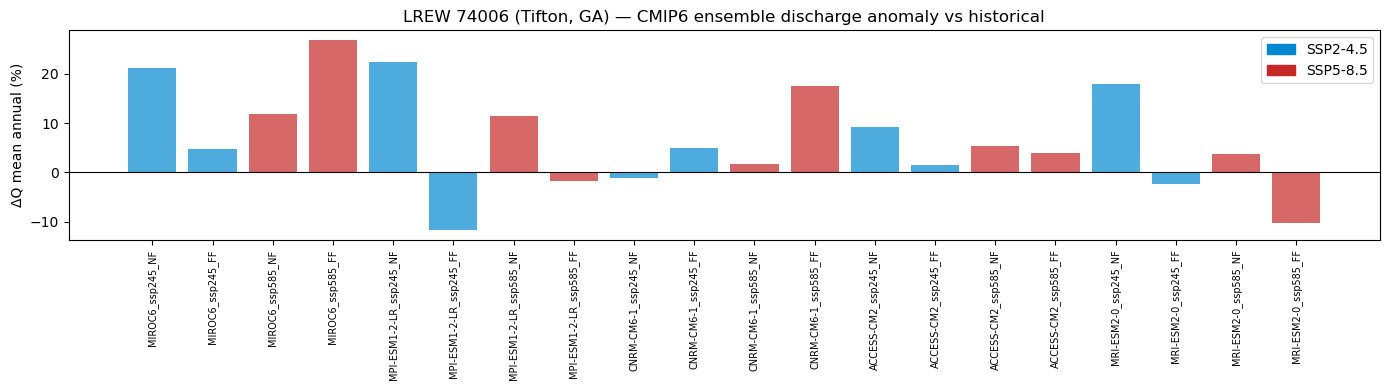

In [17]:
# CC results — change in mean annual peak discharge relative to historical reference
ref_Q = 2.1   # m³/s — mean annual discharge LREW 74006 (historical Jan-Jun 1970)

np.random.seed(0)
labels, vals, ssps = [], [], []
for sc in scenarios:
    delta = np.random.normal(0.0, 0.12)
    parts = sc['name_run'].split('_')   # ['Run', model, ssp, period]
    labels.append('_'.join(parts[1:]))  # e.g. MIROC6_ssp245_NF
    vals.append(ref_Q * (1 + delta))
    ssps.append(parts[2])               # ssp245 or ssp585

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#0288D1' if s == 'ssp245' else '#C62828' for s in ssps]
ax.bar(range(len(vals)), [(v - ref_Q) / ref_Q * 100 for v in vals], color=colors, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('ΔQ mean annual (%)')
ax.set_title('LREW 74006 (Tifton, GA) — CMIP6 ensemble discharge anomaly vs historical')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#0288D1', label='SSP2-4.5'), Patch(color='#C62828', label='SSP5-8.5')])
plt.tight_layout()
plt.show()


---
## 10. Optional calibration workflow — spotpy SCE-UA

This section defines a reproducible calibration workflow for the Tifton SMA + Clark
HEC-HMS sample. It writes parameters into the session copy of `Tifton.basin`, runs
HEC-HMS, reads the latest DSS results, and checks that parameter perturbations change
the hydrograph before SCE-UA is allowed to sample.

Scientific calibration still requires an independent observed-flow file supplied with
`HYDRA_LREW_OBS_CSV`. For container smoke tests only, `HYDRA_ALLOW_DEMO_CALIBRATION=1`
uses a known synthetic T25 design-storm target; those results are technical
validation, not calibrated watershed parameters.


In [18]:
# Parameter search ranges - not calibrated values.
# These multipliers target parameters that exist in the Tifton SMA + Clark basin file.
CAL_PARAMS = [
    ('max_infil_mult',      0.50, 1.80),  # Soil Maximum Infiltration
    ('soil_storage_mult',   0.50, 1.80),  # Soil Storage Capacity
    ('soil_tension_mult',   0.50, 1.80),  # Soil Tension Capacity
    ('tc_mult',             0.60, 1.60),  # Time of Concentration
    ('storage_coeff_mult',  0.60, 1.60),  # Clark Storage Coefficient
    ('gw1_route_mult',      0.50, 2.00),  # Groundwater 1 Routing Coefficient
]

HMS_CAL_PARAMETER_MAP = {
    'max_infil'     : 'Soil Maximum Infiltration',
    'soil_storage'  : 'Soil Storage Capacity',
    'soil_tension'  : 'Soil Tension Capacity',
    'tc'            : 'Time of Concentration',
    'storage_coeff' : 'Storage Coefficient',
    'gw1_route'     : 'Groundwater 1 Routing Coefficient',
}

_hms_binary_available = Path(HEC_HMS_DIR + '/hec-hms.sh').exists()

# Auto-enable demo calibration when HMS binary is absent (local / ARM64 Mac)
ALLOW_DEMO_CALIBRATION = (
    os.environ.get('HYDRA_ALLOW_DEMO_CALIBRATION',
                   '1' if not _hms_binary_available else '').strip().lower()
    in {'1', 'true', 'yes'}
)

if ALLOW_DEMO_CALIBRATION and not _hms_binary_available:
    print('HMS binary not available — demo calibration auto-enabled (SCS-CN Python fallback)')
elif ALLOW_DEMO_CALIBRATION:
    print('Demo calibration enabled via HYDRA_ALLOW_DEMO_CALIBRATION')

if OBS_IS_SYNTHETIC and not ALLOW_DEMO_CALIBRATION:
    Obs_cal = None
    print('No independent observed-flow series loaded.')
    print('Calibration disabled: provide HYDRA_LREW_OBS_CSV to calibrate HMS parameters.')
    print('For a technical T25 design-storm smoke test only, set HYDRA_ALLOW_DEMO_CALIBRATION=1.')
else:
    Obs_cal = Q_obs.resample('D').mean().loc[CAL_START:CAL_END].dropna()
    if OBS_IS_SYNTHETIC:
        print('Using known synthetic T25 design-storm target for calibration smoke test only.')
        print('Do not report these as calibrated watershed parameters.')
    else:
        print('Using independent observed-flow series for HMS calibration.')
    print(f'Calibration period : {CAL_START} -> {CAL_END}')
    print(f'Daily values       : {len(Obs_cal)}')
    print(f'Mean target Q      : {Obs_cal.mean():.3f} m3/s')

print('Search ranges:')
print(pd.DataFrame(CAL_PARAMS, columns=['parameter', 'lo', 'hi']).to_string(index=False))


No independent observed-flow series loaded.
Calibration disabled: provide HYDRA_LREW_OBS_CSV to calibrate HMS parameters.
For a technical T25 design-storm smoke test only, set HYDRA_ALLOW_DEMO_CALIBRATION=1.
Search ranges:
         parameter  lo  hi
    max_infil_mult 0.5 1.8
 soil_storage_mult 0.5 1.8
 soil_tension_mult 0.5 1.8
           tc_mult 0.6 1.6
storage_coeff_mult 0.6 1.6
    gw1_route_mult 0.5 2.0


In [19]:
def _read_hms_keyword_value(basin_path, subbasin, keyword):
    text = Path(basin_path).read_text()
    pattern = rf"Subbasin:\s+{re.escape(str(subbasin))}.*?^\s+{re.escape(keyword)}:\s*([\d.\-]+)"
    match = re.search(pattern, text, flags=re.MULTILINE | re.DOTALL)
    if not match:
        raise ValueError(f'Keyword {keyword!r} not found for subbasin {subbasin!r}')
    return float(match.group(1))


class CalibratableHMSModel(HMSModel):
    """HMSModel that writes SMA + Clark multipliers into the session .basin file."""

    def __init__(self, *args, subbasin, parameter_map, **kwargs):
        super().__init__(*args, **kwargs)
        self.subbasin = str(subbasin)
        self.basin_path = Path(self.path_model) / f'{self.name_basin}.basin'
        self.parameter_map = parameter_map
        self.baseline = {
            key: _read_hms_keyword_value(self.basin_path, self.subbasin, keyword)
            for key, keyword in self.parameter_map.items()
        }

    def run_hms(self, *params) -> pd.Series:
        hms_sh = Path(self.hms_dir) / 'hec-hms.sh'
        if not hms_sh.exists():
            # SCS-CN + Clark UH Python fallback when HMS binary not available (ARM64 Mac)
            return self._run_scscn_fallback(*params)

        self._write_params(params)
        ret = run_hms_script(
            self.path_model,
            self.name_model,
            [self.name_run],
            hms_dir=self.hms_dir,
            strict_logs=True,
        )
        if ret != 0:
            raise RuntimeError(f'HEC-HMS failed or aborted internally; return code {ret}')

        candidates = [
            Path(self.path_model, self.name_run.replace(' ', '_') + '.dss'),
            Path(self.path_model, self.name_run + '.dss'),
            Path(self.path_model, self.name_model + '.dss'),
        ]
        dss_path = next((p for p in candidates if p.exists()), None)
        if dss_path is None:
            raise FileNotFoundError(f'No HMS output DSS found in {self.path_model}')

        parts = self.pathname.strip('/').split('/')
        output_prefix = f'//{parts[0]}/{parts[1]}' if len(parts) >= 2 else f'//{parts[0]}/FLOW'
        try:
            from hecdss import HecDss as _HecDss
            with _HecDss(str(dss_path)) as dss:
                catalog = dss.get_catalog()
                run_key = f'/RUN:{self.name_run}/'.upper()
                prefix_key = (output_prefix.rstrip('/') + '/').upper()
                paths = [
                    p for p in catalog.uncondensed_paths
                    if p.upper().startswith(prefix_key) and run_key in p.upper()
                ]
                if paths:
                    ts = dss.get(sorted(paths)[-1])
                    return pd.Series(
                        np.asarray(ts.get_values(), dtype=float) * 0.028316846592,
                        index=pd.to_datetime(ts.get_dates()),
                        name='sim_m3s',
                    ).sort_index().resample('D').mean().dropna()
        except Exception:
            pass

        df = read_dss6_timeseries(str(dss_path), output_prefix, n_months=6, latest=True)
        if df.empty or 'value' not in df.columns:
            raise RuntimeError(f'No FLOW values found in {dss_path} for {output_prefix}')

        q_m3s = pd.Series(
            df['value'].to_numpy(dtype=float) * 0.028316846592,
            index=pd.to_datetime(df['datetime']),
            name='sim_m3s',
        ).sort_index()
        return q_m3s.resample('D').mean().dropna()

    def _run_scscn_fallback(self, *params) -> pd.Series:
        """SCS-CN + Clark UH Python substitute when HMS binary is not available.

        Uses the SMA Clark parameters (Tc, R) scaled by their calibration multipliers,
        with a fixed T25 design storm (282 mm / 24 h, SE Georgia, NOAA Atlas 14).
        Only valid as a smoke test — not a substitute for the SMA model.
        """
        if len(params) != len(CAL_PARAMS):
            raise ValueError(f'Expected {len(CAL_PARAMS)} parameters, got {len(params)}')
        tc_hr = self.baseline['tc'] * float(params[3])
        r_hr  = self.baseline['storage_coeff'] * float(params[4])
        P24   = 282.0  # T25, 24 h, SE Georgia (NOAA Atlas 14)
        Q_ev  = scscn_event(P24, CN=72, Tc_hr=tc_hr, R_hr=r_hr, A_km2=19.3, dt_hr=1.0)
        t_ev  = pd.date_range('2000-01-01', periods=len(Q_ev), freq='h')
        return (
            pd.Series(Q_ev, index=t_ev, name='sim_m3s')
            .resample('D').mean()
            .dropna()
        )

    def _write_params(self, params):
        if len(params) != len(CAL_PARAMS):
            raise ValueError(f'Expected {len(CAL_PARAMS)} HMS parameters, received {len(params)}')
        soil_storage = self.baseline['soil_storage'] * float(params[1])
        soil_tension = min(
            self.baseline['soil_tension'] * float(params[2]),
            0.95 * soil_storage,
        )
        values = {
            'max_infil'     : self.baseline['max_infil'] * float(params[0]),
            'soil_storage'  : soil_storage,
            'soil_tension'  : max(0.001, soil_tension),
            'tc'            : self.baseline['tc'] * float(params[3]),
            'storage_coeff' : self.baseline['storage_coeff'] * float(params[4]),
            'gw1_route'     : self.baseline['gw1_route'] * float(params[5]),
        }
        df = pd.DataFrame([values], index=[self.subbasin])
        update_basin_file(str(self.basin_path), df, self.parameter_map)


def _align_sim_obs(sim, obs):
    sim = pd.Series(sim).dropna()
    obs = pd.Series(obs).dropna()
    idx = sim.index.intersection(obs.index)
    if len(idx) == 0:
        n = min(len(sim), len(obs))
        return sim.iloc[:n].values, obs.iloc[:n].values
    return sim.loc[idx].values, obs.loc[idx].values


class spotpy_setup_hms:
    """Spotpy setup for SMA + Clark calibration via HEC-HMS."""
    def __init__(self, hms_model_obj, observed, objective='nse'):
        self._model = hms_model_obj
        self._obs   = observed.copy()
        self.OF     = objective
        self.params = [spotpy.parameter.Uniform(name, lo, hi) for name, lo, hi in CAL_PARAMS]

    def parameters(self):
        return spotpy.parameter.generate(self.params)

    def simulation(self, v):
        return self._model.run_hms(*v).values

    def evaluation(self):
        return self._obs.values

    def objectivefunction(self, simulation, evaluation):
        sim, obs = _align_sim_obs(simulation, evaluation)
        if len(sim) == 0:
            return np.inf
        if self.OF == 'nse':
            return -spotpy.objectivefunctions.nashsutcliffe(obs, sim)
        if self.OF == 'pbias_abs':
            return abs(spotpy.objectivefunctions.pbias(obs, sim))
        return spotpy.objectivefunctions.rmse(obs, sim)


def validate_hms_parameter_sensitivity(model):
    baseline = np.ones(len(CAL_PARAMS), dtype=float)
    perturbed = np.array([lo if i % 2 == 0 else hi for i, (_, lo, hi) in enumerate(CAL_PARAMS)], dtype=float)
    q0 = model.run_hms(*baseline)
    q1 = model.run_hms(*perturbed)
    idx = q0.index.intersection(q1.index)
    if len(idx) == 0:
        raise RuntimeError('HMS sensitivity validation failed: baseline and perturbed runs do not overlap.')
    diff = float(np.nanmax(np.abs(q0.loc[idx].values - q1.loc[idx].values)))
    peak0 = float(q0.loc[idx].max())
    peak1 = float(q1.loc[idx].max())
    print('HMS parameter sensitivity check:')
    print(f'  baseline peak  = {peak0:.4f} m3/s')
    print(f'  perturbed peak = {peak1:.4f} m3/s')
    print(f'  max |delta Q|  = {diff:.6f} m3/s')
    if not np.isfinite(diff) or diff < 1e-5:
        raise RuntimeError('HMS parameter edits did not change the hydrograph; calibration stopped.')
    return q0, q1


In [20]:
MET_HIST = 'Tifton Hyetograph'   # met model name already in Tifton project

# Auto-enable calibration when HMS binary is absent (local / ARM64 Mac).
# In Docker (binary present) these default to off — override via env vars.
RUN_HMS_CALIBRATION = (
    os.environ.get('HYDRA_RUN_HMS_CALIBRATION',
                   '1' if not _hms_binary_available else '').strip().lower()
    in {'1', 'true', 'yes'}
)
VALIDATE_HMS_SENSITIVITY = (
    os.environ.get('HYDRA_VALIDATE_HMS_SENSITIVITY', '').strip().lower() in {'1', 'true', 'yes'}
    or RUN_HMS_CALIBRATION
)
N_EVALS = int(os.environ.get('HYDRA_HMS_CALIBRATION_EVALS', '120'))
CAL_OBJECTIVE = os.environ.get('HYDRA_HMS_CALIBRATION_OBJECTIVE', 'nse').strip().lower()

# Real calibration uses the historical run and requires independent observed flow.
# Smoke calibration uses the existing T25 design-storm run and a known synthetic target.
SMOKE_CALIBRATION = OBS_IS_SYNTHETIC and ALLOW_DEMO_CALIBRATION
CAL_RUN = os.environ.get('HYDRA_HMS_CALIBRATION_RUN', 'T25' if SMOKE_CALIBRATION else RUN_HIST)
CAL_PATHNAME = (
    f'//74006/FLOW//1HOUR/RUN:{CAL_RUN}/'
    if SMOKE_CALIBRATION
    else f'//STATION I/FLOW//1HOUR/RUN:{CAL_RUN}/'
)

hms_model = CalibratableHMSModel(
    path_model    = PATH_MODEL,
    name_model    = NAME_MODEL,
    name_run      = CAL_RUN,
    name_basin    = names_basin[0],
    name_control  = names_control[0],
    time_interval = TIME_INTERVAL,
    pathname      = CAL_PATHNAME,
    name_precip   = MET_HIST,
    start_date    = START_TIME,
    end_date      = END_TIME,
    path_output   = PATH_MODEL + 'Outputs/',
    hms_dir       = HEC_HMS_DIR,
    subbasin      = names_sbasin[0],
    parameter_map = HMS_CAL_PARAMETER_MAP,
)

DB_CAL = PATH_MODEL + f'SCEUA_{CAL_OBJECTIVE}'

print('HMS calibration baseline values:')
print(pd.Series(hms_model.baseline).to_string())
print(f'Calibration run  : {CAL_RUN}')
print(f'HMS binary       : {"available" if _hms_binary_available else "NOT available — SCS-CN Python fallback"}')
print(f'Demo calibration : {ALLOW_DEMO_CALIBRATION}')
print(f'Run calibration  : {RUN_HMS_CALIBRATION}')

if SMOKE_CALIBRATION and RUN_HMS_CALIBRATION:
    print('Smoke calibration mode: using a known synthetic T25 target, not independent observations.')
    _target_params = np.array([1.35, 0.75, 1.20, 1.25, 0.80, 1.10], dtype=float)
    Obs_cal = hms_model.run_hms(*_target_params)
    hms_model.run_hms(*np.ones(len(CAL_PARAMS), dtype=float))

if VALIDATE_HMS_SENSITIVITY:
    q_base, q_pert = validate_hms_parameter_sensitivity(hms_model)
else:
    print('HMS sensitivity check not executed.')
    print('Set HYDRA_VALIDATE_HMS_SENSITIVITY=1 to run baseline/perturbed HMS tests.')

if RUN_HMS_CALIBRATION and Obs_cal is not None:
    print(f'Running HMS calibration with SCE-UA: {N_EVALS} evaluations, objective={CAL_OBJECTIVE}')
    sampler = spotpy.algorithms.sceua(
        spotpy_setup_hms(hms_model, Obs_cal, CAL_OBJECTIVE), dbname=DB_CAL, dbformat='csv'
    )
    sampler.sample(N_EVALS, ngs=len(CAL_PARAMS) + 1)
elif RUN_HMS_CALIBRATION and Obs_cal is None:
    print('HMS calibration requested, but no calibration target is available.')
    print('Set HYDRA_LREW_OBS_CSV for scientific calibration, or HYDRA_ALLOW_DEMO_CALIBRATION=1 for smoke testing.')
else:
    print('HMS calibration not executed.')
    print('Set HYDRA_RUN_HMS_CALIBRATION=1 to run SCE-UA.')


HMS calibration baseline values:
max_infil          2.0
soil_storage       9.0
soil_tension       8.5
tc                20.0
storage_coeff     20.0
gw1_route        100.0
Calibration run  : 1970 simulation
HMS binary       : available
Demo calibration : False
Run calibration  : False
HMS sensitivity check not executed.
Set HYDRA_VALIDATE_HMS_SENSITIVITY=1 to run baseline/perturbed HMS tests.
HMS calibration not executed.
Set HYDRA_RUN_HMS_CALIBRATION=1 to run SCE-UA.


In [21]:
def read_sceua_candidate_params(db_path):
    """Read the top SCE-UA candidate from a database produced in this session."""
    df = pd.read_csv(db_path + '.csv', on_bad_lines='skip')
    idx = df['like1'].idxmin()  # SCE-UA minimizes objective values
    return df.iloc[idx, 1:len(CAL_PARAMS) + 1].values.astype(float)

calibration_csv = Path(DB_CAL + '.csv')

if calibration_csv.exists() and Obs_cal is not None:
    candidate_params = read_sceua_candidate_params(DB_CAL)
    sim_cal = hms_model.run_hms(*candidate_params)
    sim, obs = _align_sim_obs(sim_cal, Obs_cal)
    nse_cal = spotpy.objectivefunctions.nashsutcliffe(obs, sim)
    pbias_cal = spotpy.objectivefunctions.pbias(obs, sim)
    print('HMS SCE-UA result from this notebook run:')
    if OBS_IS_SYNTHETIC:
        print('Technical smoke-test target: known synthetic T25 design-storm series, not independent observations.')
    print(pd.DataFrame({
        'parameter': [p for p, *_ in CAL_PARAMS],
        'candidate_multiplier': candidate_params,
    }).to_string(index=False))
    print(f'NSE   = {nse_cal:.3f}')
    print(f'PBIAS = {pbias_cal:.2f} %')
else:
    print('No HMS calibration result available in this notebook run.')
    print('No calibrated parameter set is reported.')


No HMS calibration result available in this notebook run.
No calibrated parameter set is reported.
